In [1]:
%pip install polars



Note: you may need to restart the kernel to use updated packages.


In [2]:
from io import StringIO

import requests
import polars as pl
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
# Define API query URL (CSV with labels format)
url = 'https://sdmx.oecd.org/public/rest/data/OECD.WISE.CWB,DSD_CWB@DF_CWB,/all?dimensionAtObservation=AllDimensions&format=csvfile'
# Fetch data
response = requests.get(url)

# Load into polars DataFrame
df = pl.read_csv(StringIO(response.text))

In [4]:
# Filters

## Keep only the measures with the lowest number of missing values for the years 2009,2012,2015,2018
measures = [
    'A1_2','A1_4', #Material outcome
    'A2_1', # Physical health outcome
    'A3_3','A3_4','A3_5', #Cognitive & educational outcome
    'A4_6', #Social & emotional outcome
    'B1_1','B1_5', #Home & Family Life
    'B2_1','B2_4','B2_5', #Life at school & early education and care
    'B3_5', #Social Life and life in the community
    'B4_3', #Life online
    'C1_1','C1_2','C1_3','C1_4','C1_5', #Family policies
    'C2_1','C2_2','C2_3', #House & Community policies
    'C3_1','C3_2','C3_3', #Health policies
    'C4_1','C4_2','C4_3','C4_4','C4_5','C4_6', #Education & eary childhood policies
    'C5_1', #Environmental policies
]

## Keep only the European countries
areas = [
    'SWE', 'DNK', 'NOR', 'FIN', 'ISL', 'LTU', 'LVA', 'EST', #Northern Europe
    'IRL', 'GBR', 'NLD', 'BEL', 'FRA', 'LUX', 'CHE', 'AUT', 'DEU', #Western Europe
    'ESP', 'PRT', 'ITA', 'GRC', 'SVN', 'HRV', 'TUR', #Southern Europe
    'POL', 'CZE', 'SVK', 'HUN', 'ROU', 'BGR', #Eastern Europe
]

## Keep only a subset of years
years = [2009, 2012, 2015, 2018]

In [5]:
# Apply the filters on the dataframe
df = df.filter(
    pl.col('MEASURE').is_in(measures) &
    pl.col('REF_AREA').is_in(areas) &
    pl.col('TIME_PERIOD').is_in(years)
)

In [6]:
df.head(10)

DATAFLOW,REF_AREA,MEASURE,DOMAIN,TIME_PERIOD,OBS_VALUE,OBS_STATUS,UNIT_MULT,UNIT_MEASURE,BASE_PER,DECIMALS,POP_GROUP
str,str,str,str,i64,f64,str,i64,str,i64,i64,str
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2009,204.6,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2012,186.1,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2015,175.4,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2018,169.8,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2009,182.4,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2012,184.7,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2015,130.7,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2018,162.4,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""CZE""","""C2_1""","""C2""",2009,305.8,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""


In [7]:
# Create a grid with all the combinations of area and time period
df_grid = pl.DataFrame()

years = df.select('TIME_PERIOD').unique().to_series().to_list()

for area in areas:
    for year in years:
        df_grid = df_grid.vstack(
            pl.DataFrame(
                {
                    'REF_AREA': area,
                    'TIME_PERIOD': year,
                }
            )
        )

#Populate the grid with the measures in a wide format
for measure in measures:
    df_temp = df.filter(
        pl.col('MEASURE') == measure
    ).select(
        ['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']
    ).with_columns(
        pl.col('OBS_VALUE').alias(measure)
    ).select(
        ['REF_AREA', 'TIME_PERIOD', measure]
    )
    df_grid = df_grid.join(
        df_temp,
        on=['REF_AREA', 'TIME_PERIOD'],
        how='left'
    )

In [8]:
df_grid.head(50)

#fare controllo per paese dei missing


REF_AREA,TIME_PERIOD,A1_2,A1_4,A2_1,A3_3,A3_4,A3_5,A4_6,B1_1,B1_5,B2_1,B2_4,B2_5,B3_5,B4_3,C1_1,C1_2,C1_3,C1_4,C1_5,C2_1,C2_2,C2_3,C3_1,C3_2,C3_3,C4_1,C4_2,C4_3,C4_4,C4_5,C4_6,C5_1
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SWE""",2009,null,1.5,2.5,15.9,null,11.0,null,null,null,null,null,null,null,null,9185.3,null,41.0,60.0,10.0,259.4,580.5,134.9,3026.3,98.0,97.0,9525.1,null,null,10602.2,null,null,204.8
"""SWE""",2015,4.4,1.7,2.5,16.7,58.9,9.1,null,9.1,59.5,null,17.9,69.3,12.4,37.4,9818.3,7.0,37.0,60.0,10.0,289.1,621.9,155.9,4201.5,98.0,98.0,10716.7,5.0,6.4,11581.8,1220.3,13.4,208.7
"""SWE""",2018,5.0,1.0,2.0,19.4,69.8,8.9,32.6,9.0,46.4,46.3,19.2,67.0,15.5,33.5,null,6.9,37.0,55.7,14.3,362.5,635.5,143.3,4389.6,97.0,97.0,null,5.0,6.3,12368.5,1254.5,12.3,252.8
"""SWE""",2012,2.4,0.7,2.6,12.4,null,9.7,null,null,null,null,null,null,11.7,null,9748.8,null,39.0,60.0,10.0,242.6,603.6,154.0,3960.1,98.0,98.0,10194.2,6.0,null,11262.5,null,null,214.1
"""DNK""",2009,null,1.1,3.1,13.9,null,8.8,null,null,null,null,null,null,null,null,10374.4,null,61.0,50.0,2.0,234.4,866.0,313.9,3824.1,89.0,84.0,9424.0,null,null,12717.1,null,null,204.8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""BEL""",2015,1.5,1.6,3.3,19.7,60.4,13.8,null,null,49.0,54.4,18.5,62.0,16.6,32.4,8710.5,8.4,37.0,32.3,19.3,130.7,560.5,91.7,3534.3,99.0,96.0,5393.1,13.0,15.1,11515.1,210.5,9.6,584.4
"""BEL""",2018,3.9,1.0,3.8,19.4,68.8,12.8,null,9.2,42.0,56.8,18.6,58.2,12.4,28.7,null,11.6,36.0,32.3,19.3,162.4,619.6,98.9,3809.9,98.0,96.0,null,12.0,14.5,11626.6,233.2,9.4,613.1
"""BEL""",2012,0.9,1.8,3.8,22.3,null,15.0,null,null,null,51.4,null,null,15.4,null,8670.3,8.8,37.0,32.3,19.3,184.7,616.5,76.2,3468.1,99.0,96.0,4777.0,13.0,16.2,11541.1,173.9,null,709.8


In [ ]:
df_grid.write_parquet('../data/child_well_being-grid.parquet')

Missing analysis

In [10]:

colonne_variabili = [col for col in df_grid.columns if col not in ["REF_AREA", "TIME_PERIOD"]]
n_colonne = len(colonne_variabili)

# 2. Calcoliamo i nulli riga per riga PRIMA del group_by (approccio più lineare e sicuro)
df_con_nulli = df_grid.with_columns(
    pl.sum_horizontal(pl.col(colonne_variabili).is_null()).alias("tot_null_riga")
)

# 3. Raggruppiamo facendo la somma dei nulli totali del gruppo
report_null = (
    df_con_nulli.group_by(["TIME_PERIOD", "REF_AREA"])
    .agg(
        (pl.col("tot_null_riga").sum() / (pl.len() * n_colonne) * 100).alias("pct_null")
    )
    .sort(["TIME_PERIOD", "pct_null"], descending=[False, True])
)

# 4. Stampa nel formato richiesto
for anno, gruppo in report_null.group_by("TIME_PERIOD"):
    print(f"\n{anno}:")
    for riga in gruppo.iter_rows(named=True):
        print(f"  {riga['REF_AREA'].lower()} {riga['pct_null']:.1f}% null")
        


(2009,):
  hrv 87.5% null
  bgr 81.2% null
  rou 81.2% null
  tur 68.8% null
  deu 50.0% null
  est 50.0% null
  aut 50.0% null
  swe 46.9% null
  ltu 46.9% null
  nld 46.9% null
  dnk 46.9% null
  che 43.8% null
  lux 43.8% null
  fra 43.8% null
  hun 40.6% null
  esp 40.6% null
  fin 40.6% null
  nor 40.6% null
  grc 40.6% null
  gbr 40.6% null
  lva 40.6% null
  svn 40.6% null
  prt 37.5% null
  irl 37.5% null
  isl 37.5% null
  bel 37.5% null
  cze 37.5% null
  ita 34.4% null
  svk 34.4% null
  pol 34.4% null

(2012,):
  hrv 81.2% null
  bgr 71.9% null
  rou 71.9% null
  tur 53.1% null
  swe 37.5% null
  lva 34.4% null
  est 34.4% null
  ltu 34.4% null
  che 34.4% null
  irl 34.4% null
  dnk 31.2% null
  nld 31.2% null
  isl 31.2% null
  nor 31.2% null
  svn 31.2% null
  lux 28.1% null
  fin 28.1% null
  prt 28.1% null
  aut 28.1% null
  grc 28.1% null
  ita 25.0% null
  gbr 25.0% null
  cze 25.0% null
  esp 25.0% null
  deu 25.0% null
  bel 25.0% null
  hun 25.0% null
  pol 21.9%

In [11]:
# Selecting countries that have more than 50% of missin values
nazioni_critiche = (
    report_null.filter(pl.col("pct_null") > 50)
    .select("REF_AREA")
    .unique()["REF_AREA"]
    .to_list()
)

print("\nNazioni con più del 50% di null (in almeno un periodo):")
print(nazioni_critiche)


Nazioni con più del 50% di null (in almeno un periodo):
['TUR', 'ROU', 'BGR', 'HRV']


In [12]:
#elimination of rows 

righe_iniziali = df_grid.height

df_grid_filtrato = df_grid.filter(~pl.col("REF_AREA").is_in(nazioni_critiche))

righe_finali = df_grid_filtrato.height
righe_rimosse = righe_iniziali - righe_finali

print(f"Numero di righe rimosse: {righe_rimosse}")
print(f"Dimensioni del DataFrame originale: {df_grid.shape}")
print(f"Dimensioni del nuovo DataFrame filtrato: {df_grid_filtrato.shape}")

Numero di righe rimosse: 16
Dimensioni del DataFrame originale: (120, 34)
Dimensioni del nuovo DataFrame filtrato: (104, 34)


Analisi dei missing

In [17]:
# Conto null per ogni colonna e calcolo la percentuale.
n_rows = df_grid.height

print('missing percentage before the elimination of critical countries')
missing = (
    df_grid.null_count()                         
           .transpose(include_header=True,
                      header_name="colonna",
                      column_names=["n_missing"])
           .with_columns(
               (pl.col("n_missing") / n_rows * 100).round(2).alias("pct_missing")
           )
           .sort("pct_missing", descending=True)
)
print(missing)


missing percentage before the elimination of critical countries
shape: (34, 3)
┌─────────────┬───────────┬─────────────┐
│ colonna     ┆ n_missing ┆ pct_missing │
│ ---         ┆ ---       ┆ ---         │
│ str         ┆ u32       ┆ f64         │
╞═════════════╪═══════════╪═════════════╡
│ C4_6        ┆ 73        ┆ 60.83       │
│ A4_6        ┆ 68        ┆ 56.67       │
│ B4_3        ┆ 67        ┆ 55.83       │
│ C4_3        ┆ 66        ┆ 55.0        │
│ B2_4        ┆ 63        ┆ 52.5        │
│ …           ┆ …         ┆ …           │
│ A3_3        ┆ 2         ┆ 1.67        │
│ C1_3        ┆ 2         ┆ 1.67        │
│ A1_4        ┆ 1         ┆ 0.83        │
│ REF_AREA    ┆ 0         ┆ 0.0         │
│ TIME_PERIOD ┆ 0         ┆ 0.0         │
└─────────────┴───────────┴─────────────┘


In [18]:

print('missing percentage after the elimination of critical countries')
missing = (
    df_grid_filtrato.null_count()                         
           .transpose(include_header=True,
                      header_name="colonna",
                      column_names=["n_missing"])
           .with_columns(
               (pl.col("n_missing") / n_rows * 100).round(2).alias("pct_missing")
           )
           .sort("pct_missing", descending=True)
)
print(missing)

missing percentage after the elimination of critical countries
shape: (34, 3)
┌─────────┬───────────┬─────────────┐
│ colonna ┆ n_missing ┆ pct_missing │
│ ---     ┆ ---       ┆ ---         │
│ str     ┆ u32       ┆ f64         │
╞═════════╪═══════════╪═════════════╡
│ A4_6    ┆ 59        ┆ 49.17       │
│ C4_6    ┆ 59        ┆ 49.17       │
│ B4_3    ┆ 56        ┆ 46.67       │
│ B2_4    ┆ 54        ┆ 45.0        │
│ B1_5    ┆ 53        ┆ 44.17       │
│ …       ┆ …         ┆ …           │
│ C2_3    ┆ 0         ┆ 0.0         │
│ C3_1    ┆ 0         ┆ 0.0         │
│ C3_2    ┆ 0         ┆ 0.0         │
│ C3_3    ┆ 0         ┆ 0.0         │
│ C5_1    ┆ 0         ┆ 0.0         │
└─────────┴───────────┴─────────────┘


In [28]:
# we compute the null percetange for each year-variable combination 
indicatori = [c for c in df_grid_filtrato.columns if c not in ("REF_AREA", "TIME_PERIOD")]

missing_per_year = (
    df_grid_filtrato
    .group_by("TIME_PERIOD")
    .agg([
        (pl.col(c).is_null().sum() / pl.len() * 100).round(1).alias(c)
        for c in indicatori
    ])
    .sort("TIME_PERIOD")
)
print("Percentuale missing per indicatore e anno:")
missing_per_year



Percentuale missing per indicatore e anno:


TIME_PERIOD,A1_2,A1_4,A2_1,A3_3,A3_4,A3_5,A4_6,B1_1,B1_5,B2_1,B2_4,B2_5,B3_5,B4_3,C1_1,C1_2,C1_3,C1_4,C1_5,C2_1,C2_2,C2_3,C3_1,C3_2,C3_3,C4_1,C4_2,C4_3,C4_4,C4_5,C4_6,C5_1
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2009,100.0,3.8,0.0,3.8,61.5,3.8,100.0,30.8,100.0,57.7,100.0,100.0,100.0,100.0,7.7,19.2,0.0,15.4,15.4,0.0,0.0,0.0,0.0,0.0,0.0,3.8,100.0,100.0,23.1,88.5,100.0,0.0
2012,3.8,0.0,0.0,0.0,100.0,7.7,100.0,15.4,100.0,46.2,100.0,100.0,3.8,100.0,7.7,3.8,0.0,11.5,11.5,0.0,0.0,0.0,0.0,0.0,0.0,3.8,0.0,65.4,3.8,38.5,96.2,0.0
2015,3.8,0.0,0.0,0.0,3.8,3.8,15.4,3.8,0.0,53.8,3.8,0.0,3.8,3.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.8,0.0,23.1,3.8,15.4,19.2,0.0
2018,3.8,0.0,0.0,3.8,11.5,0.0,11.5,3.8,3.8,3.8,3.8,0.0,3.8,11.5,92.3,3.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,92.3,0.0,11.5,0.0,11.5,11.5,0.0


In [31]:
colonne_indicatori = [c for c in df_grid_filtrato.columns if c not in ("REF_AREA", "TIME_PERIOD")]
n_colonne = len(colonne_indicatori)

report = (
    df_grid_filtrato.group_by("TIME_PERIOD")
    .agg(
        pl.len().alias("num_paesi"),
        ((pl.sum_horizontal(pl.col(colonne_indicatori).is_null()).sum() / (pl.len() * n_colonne)) * 100)
        .round(1)
        .alias("pct_missing_medio")
    )
    .sort("TIME_PERIOD")
)

print(report)

shape: (4, 3)
┌─────────────┬───────────┬───────────────────┐
│ TIME_PERIOD ┆ num_paesi ┆ pct_missing_medio │
│ ---         ┆ ---       ┆ ---               │
│ i64         ┆ u32       ┆ f64               │
╞═════════════╪═══════════╪═══════════════════╡
│ 2009        ┆ 26        ┆ 41.7              │
│ 2012        ┆ 26        ┆ 28.7              │
│ 2015        ┆ 26        ┆ 5.0               │
│ 2018        ┆ 26        ┆ 8.9               │
└─────────────┴───────────┴───────────────────┘


In [30]:
#drop of rows having TIME_PERIOD equal to 2009 o 2012 

df_grid_final = df_grid_filtrato.filter(~pl.col("TIME_PERIOD").is_in([2009, 2012]))

print("Years left in the dataframe:")
print(df_grid_final["TIME_PERIOD"].unique().to_list())

print(f"\nNew shape: {df_grid_final.shape}")

Years left in the dataframe:
[2015, 2018]

New shape: (52, 34)


In [34]:

colonne_indicatori = [c for c in df_grid_final.columns if c not in ("REF_AREA", "TIME_PERIOD")]
n_colonne = len(colonne_indicatori)

df_partizionato = df_grid_final.partition_by("TIME_PERIOD", as_dict=True)
df_per_anno = {chiave[0]: sotto_df for chiave, sotto_df in df_partizionato.items()}



Analisi correlazioni 

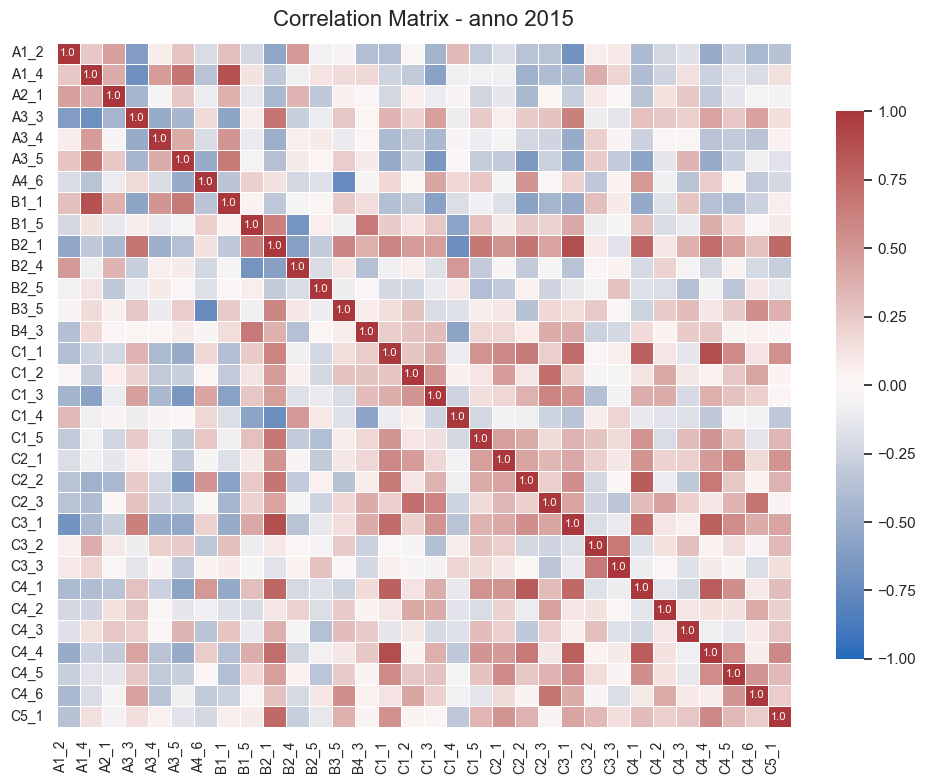

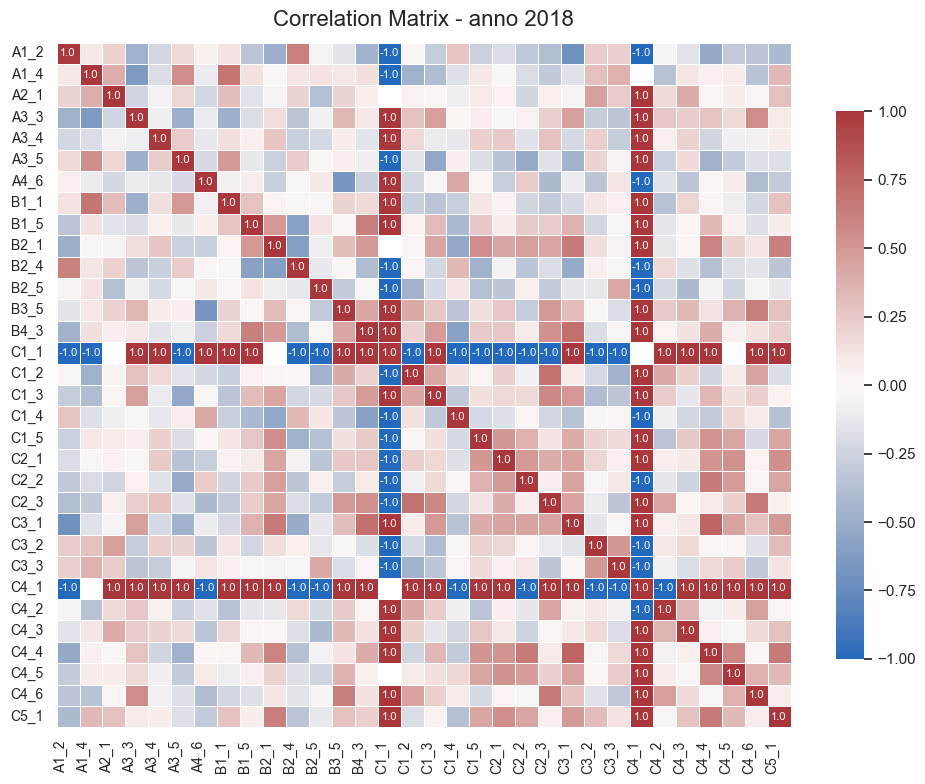

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")  

for a, sub in df_per_anno.items():

    df = pd.DataFrame(sub).replace(to_replace="null", value=np.nan).iloc[:, 2:]
    col= sub.columns[2:]
    df.columns = col
    corr = df.corr()

    annot = corr.round(2).astype(str)
    annot = annot.where(corr.abs() > 0.90, "")

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        corr,
        cmap="vlag",         
        center=0,
        vmin=-1,
        vmax=1,
        annot=annot,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.8}, 
        annot_kws={"size": 8}, 

    )
    ax.set_title(f"Correlation Matrix - anno {a}", fontsize=16, pad=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.show()



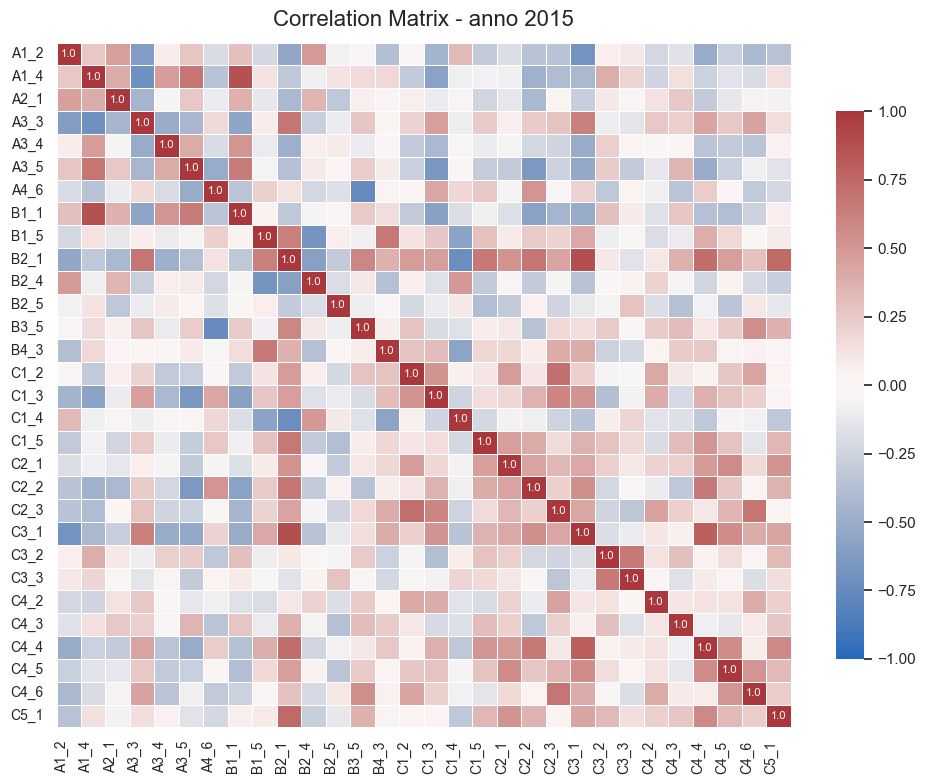

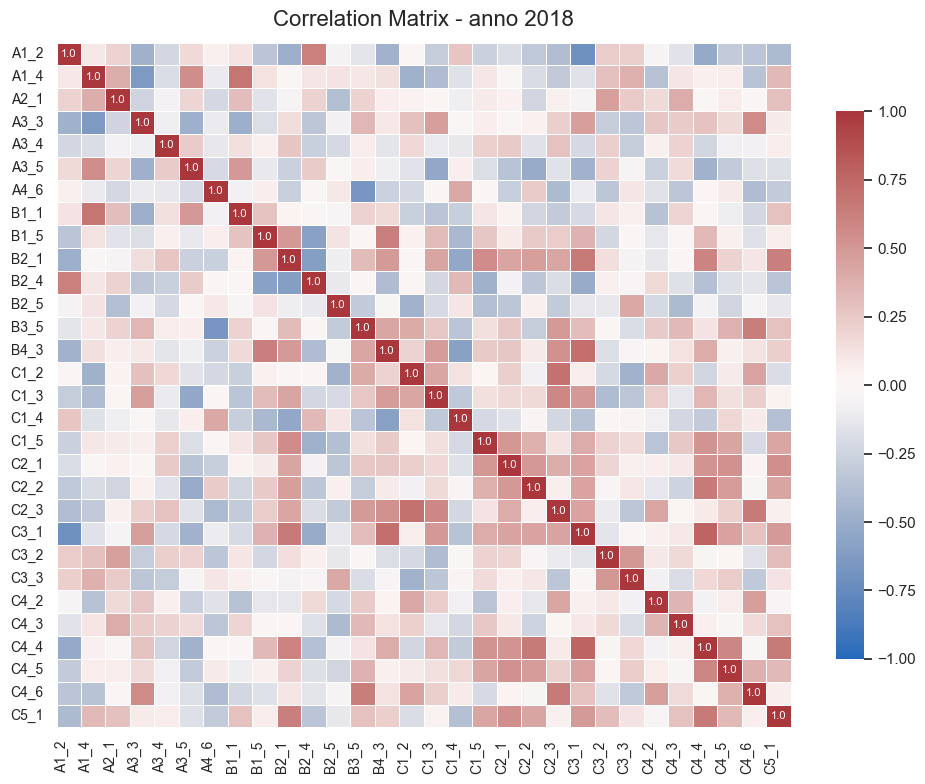

In [39]:

sns.set_theme(style="white")  

for a, sub in df_per_anno.items():
    sub = sub.drop(["C4_1", "C1_1"]) #removing highly correlated columns
    df = pd.DataFrame(sub).replace(to_replace="null", value=np.nan).iloc[:, 2:]
    col= sub.columns[2:]
    df.columns = col
    corr = df.corr()

    annot = corr.round(2).astype(str)
    annot = annot.where(corr.abs() > 0.90, "")

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        corr,
        cmap="vlag",         
        center=0,
        vmin=-1,
        vmax=1,
        annot=annot,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.8}, 
        annot_kws={"size": 8}, 

    )
    ax.set_title(f"Correlation Matrix - anno {a}", fontsize=16, pad=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.show()



In [ ]:
#dropping columns C4_1 and C1_1 due to hight correlation with other columns and re-running the correlation analysis

Split dei dataframe annuali in investimenti e outcome

In [41]:

chiavi = ["REF_AREA", "TIME_PERIOD"]
cols_to_exclude = {"C4_1", "C1_1"}
variabili_investimenti = [
    "C1_1",
    "C2_1", "C2_2", "C2_3",
    "C3_1", 
    "C4_4", "C4_5", 
    "C5_1"
]
variabili_investimenti_presenti = [
    c for c in variabili_investimenti
    if c in df_grid_final.columns and c not in cols_to_exclude
]

variabili_outcome_presenti = [
    c for c in df_grid_final.columns
    if c not in chiavi and c not in variabili_investimenti_presenti and c not in cols_to_exclude
]

print("Variabili investimenti presenti:", variabili_investimenti_presenti)
print("N investimenti:", len(variabili_investimenti_presenti))

print("\nVariabili outcome presenti:", variabili_outcome_presenti)
print("N outcome:", len(variabili_outcome_presenti))


Variabili investimenti presenti: ['C2_1', 'C2_2', 'C2_3', 'C3_1', 'C4_4', 'C4_5', 'C5_1']
N investimenti: 7

Variabili outcome presenti: ['A1_2', 'A1_4', 'A2_1', 'A3_3', 'A3_4', 'A3_5', 'A4_6', 'B1_1', 'B1_5', 'B2_1', 'B2_4', 'B2_5', 'B3_5', 'B4_3', 'C1_2', 'C1_3', 'C1_4', 'C1_5', 'C3_2', 'C3_3', 'C4_2', 'C4_3', 'C4_6']
N outcome: 23


In [42]:
df_investimenti_per_anno = {
    a: sub.select(chiavi + variabili_investimenti_presenti)
    for a, sub in df_per_anno.items()
}

df_outcome_per_anno = {
    a: sub.select(chiavi + variabili_outcome_presenti)
    for a, sub in df_per_anno.items()
}
